# Decoder analysis


In [1]:
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    %cd /content/kalnet
    %pip install -e .
else:
    # update for your local path
    %cd /home/jacob/kalnet


/home/jacob/kalnet


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from kalnet.decoders import (
    LinearDecoder,
    NonlinearDecoder,
    PerTimestepCenterer,
    opt_precision,
    pool_timesteps,
    select_trials,
    trial_train_validation_indices,
)
from kalnet.leace import LeaceEraser


## Opt-precision Decoders

Load the batch-100 dataset produced by `correlation_analysis.ipynb`. **Per-timestep centering** removes the across-Trial mean of hidden states and of Opt precision at each timestep (means fit on train Trials only), then every Trial × timestep is pooled. Trials are split before pooling so a Trial cannot leak between training and validation.

A `LinearDecoder` (Ridge) measures linear accessibility; a `NonlinearDecoder` (one-hidden-layer ReLU MLP) tests whether a simple nonlinear probe performs better. Both are evaluated on held-out test Trials.

The Ridge coefficient is compared with the trained network readout using absolute cosine similarity (parallel and anti-parallel count as the same axis).


In [3]:
dataset = torch.load("saved_data/kf_dataset_100.pt", map_location="cpu", weights_only=False)
checkpoint = torch.load("checkpoints/kf_batch100.pt", map_location="cpu", weights_only=False)

train_split = dataset["train"]
test_split = dataset["test"]
train_idx, val_idx = trial_train_validation_indices(train_split["r_hid"].shape[0])

train_trials = select_trials(train_split, train_idx)
val_trials = select_trials(train_split, val_idx)
test_trials = select_trials(test_split)

centerer = PerTimestepCenterer().fit(
    hidden=train_trials["r_hid"],
    opt_mean=train_trials["mu"],
    opt_precision=opt_precision(train_trials["sigma_sq"]),
)


def prepare_probe_tensors(trials):
    hidden = centerer.transform("hidden", trials["r_hid"])
    mean = centerer.transform("opt_mean", trials["mu"])
    precision = centerer.transform(
        "opt_precision", opt_precision(trials["sigma_sq"])
    )
    return (
        pool_timesteps(hidden),
        pool_timesteps(mean),
        pool_timesteps(precision),
    )


X_train, mean_train, precision_train = prepare_probe_tensors(train_trials)
X_validation, mean_validation, precision_validation = prepare_probe_tensors(val_trials)
X_test, mean_test, precision_test = prepare_probe_tensors(test_trials)

linear_precision = LinearDecoder().fit(X_train, precision_train)
nonlinear_precision = NonlinearDecoder(n_in=X_train.shape[1]).fit(
    X_train,
    precision_train,
    X_validation,
    precision_validation,
)

precision_linear_test_pred = linear_precision.predict(X_test)
precision_nonlinear_test_pred = nonlinear_precision.predict(X_test)
precision_linear_test_r2 = linear_precision.r2(X_test, precision_test)
precision_nonlinear_test_r2 = nonlinear_precision.r2(X_test, precision_test)

readout = (
    checkpoint["state_dict"]["readout.weight"].detach().cpu().numpy().reshape(-1)
)
coef = linear_precision.coef_
abs_cos = float(
    abs(np.dot(coef, readout)) / (np.linalg.norm(coef) * np.linalg.norm(readout))
)
acute_angle = float(np.degrees(np.arccos(np.clip(abs_cos, 0.0, 1.0))))

print(
    f"Pooled samples: train={len(X_train):,}, "
    f"validation={len(X_validation):,}, test={len(X_test):,}"
)
print(
    f"Selected MLP epoch {nonlinear_precision.best_epoch} on validation: "
    f"linear R²={linear_precision.r2(X_validation, precision_validation):.4f}, "
    f"nonlinear R²={nonlinear_precision.r2(X_validation, precision_validation):.4f}"
)
print(f"Linear test R²:                 {precision_linear_test_r2:.4f}")
print(f"Nonlinear test R²:              {precision_nonlinear_test_r2:.4f}")
print(
    f"Nonlinear advantage (ΔR²):      "
    f"{precision_nonlinear_test_r2 - precision_linear_test_r2:+.4f}"
)
print(f"Precision/readout |cosine|:     {abs_cos:.4f}")
print(f"Precision/readout acute angle:  {acute_angle:.2f}°")


Pooled samples: train=100,000, validation=25,000, test=50,000
Selected MLP epoch 96 on validation: linear R²=0.9863, nonlinear R²=0.9969
Linear test R²:                 0.9859
Nonlinear test R²:              0.9968
Nonlinear advantage (ΔR²):      +0.0109
Precision/readout |cosine|:     0.0512
Precision/readout acute angle:  87.06°


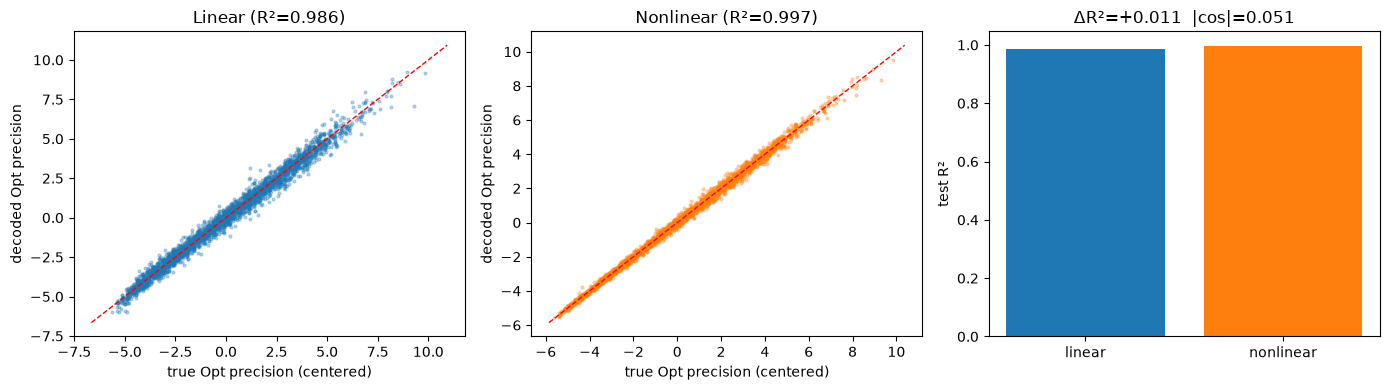

In [4]:
y_test = precision_test.reshape(-1).numpy()
rng = np.random.default_rng(0)
idx = rng.choice(len(y_test), size=min(3000, len(y_test)), replace=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(y_test[idx], precision_linear_test_pred[idx], s=4, alpha=0.3)
lims = [
    min(y_test.min(), precision_linear_test_pred.min()),
    max(y_test.max(), precision_linear_test_pred.max()),
]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_xlabel("true Opt precision (centered)")
axes[0].set_ylabel("decoded Opt precision")
axes[0].set_title(f"Linear (R²={precision_linear_test_r2:.3f})")

axes[1].scatter(
    y_test[idx],
    precision_nonlinear_test_pred[idx],
    s=4,
    alpha=0.3,
    color="tab:orange",
)
lims = [
    min(y_test.min(), precision_nonlinear_test_pred.min()),
    max(y_test.max(), precision_nonlinear_test_pred.max()),
]
axes[1].plot(lims, lims, "r--", linewidth=1)
axes[1].set_xlabel("true Opt precision (centered)")
axes[1].set_ylabel("decoded Opt precision")
axes[1].set_title(f"Nonlinear (R²={precision_nonlinear_test_r2:.3f})")

axes[2].bar(
    ["linear", "nonlinear"],
    [precision_linear_test_r2, precision_nonlinear_test_r2],
    color=["tab:blue", "tab:orange"],
)
axes[2].set_ylabel("test R²")
axes[2].set_title(
    f"ΔR²={precision_nonlinear_test_r2 - precision_linear_test_r2:+.3f}  "
    f"|cos|={abs_cos:.3f}"
)

plt.tight_layout()
plt.show()


## LEACE: erase Opt mean, then decode

Fit a **LEACE eraser** on train samples to remove linearly available Opt mean from the centered hidden states (Belrose et al. 2023). Then re-run `LinearDecoder` and `NonlinearDecoder` for both Opt mean (sanity check) and Opt precision (main question: does precision coding survive?).

Uses the same Per-timestep-centered tensors prepared above.


In [5]:
linear_mean = LinearDecoder().fit(X_train, mean_train)
nonlinear_mean = NonlinearDecoder(n_in=X_train.shape[1], seed=1).fit(
    X_train,
    mean_train,
    X_validation,
    mean_validation,
)

mean_linear_before = linear_mean.r2(X_test, mean_test)
mean_nonlinear_before = nonlinear_mean.r2(X_test, mean_test)
precision_linear_before = precision_linear_test_r2
precision_nonlinear_before = precision_nonlinear_test_r2

eraser = LeaceEraser.fit(X_train, mean_train)
X_train_erased = eraser.transform(X_train)
X_validation_erased = eraser.transform(X_validation)
X_test_erased = eraser.transform(X_test)

linear_mean_after = LinearDecoder().fit(X_train_erased, mean_train)
nonlinear_mean_after = NonlinearDecoder(n_in=X_train.shape[1], seed=2).fit(
    X_train_erased,
    mean_train,
    X_validation_erased,
    mean_validation,
)
linear_precision_after = LinearDecoder().fit(X_train_erased, precision_train)
nonlinear_precision_after = NonlinearDecoder(n_in=X_train.shape[1], seed=3).fit(
    X_train_erased,
    precision_train,
    X_validation_erased,
    precision_validation,
)

mean_linear_after = linear_mean_after.r2(X_test_erased, mean_test)
mean_nonlinear_after = nonlinear_mean_after.r2(X_test_erased, mean_test)
precision_linear_after = linear_precision_after.r2(X_test_erased, precision_test)
precision_nonlinear_after = nonlinear_precision_after.r2(
    X_test_erased, precision_test
)

rows = [
    ("Opt mean", "linear", mean_linear_before, mean_linear_after),
    ("Opt mean", "nonlinear", mean_nonlinear_before, mean_nonlinear_after),
    ("Opt precision", "linear", precision_linear_before, precision_linear_after),
    (
        "Opt precision",
        "nonlinear",
        precision_nonlinear_before,
        precision_nonlinear_after,
    ),
]

print(f"{'target':<14} {'decoder':<10} {'before':>8} {'after':>8} {'Δ':>8}")
for target, decoder, before, after in rows:
    print(
        f"{target:<14} {decoder:<10} {before:8.4f} {after:8.4f} {after - before:+8.4f}"
    )


target         decoder      before    after        Δ
Opt mean       linear       0.9996  -0.0000  -0.9997
Opt mean       nonlinear    0.9997   0.9989  -0.0009
Opt precision  linear       0.9859   0.9859  -0.0000
Opt precision  nonlinear    0.9968   0.9964  -0.0004


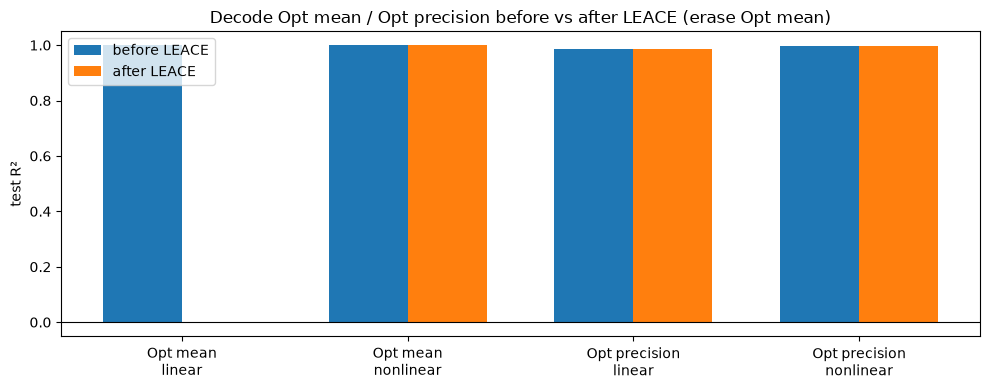

In [6]:
labels = [f"{t}\n{d}" for t, d, _, _ in rows]
before_vals = [b for _, _, b, _ in rows]
after_vals = [a for _, _, _, a in rows]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width / 2, before_vals, width, label="before LEACE", color="tab:blue")
ax.bar(x + width / 2, after_vals, width, label="after LEACE", color="tab:orange")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("test R²")
ax.set_title("Decode Opt mean / Opt precision before vs after LEACE (erase Opt mean)")
ax.legend()
ax.axhline(0.0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()
